# Logscale

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import scipy.stats as ss
import vega_datasets

## Ratio and logarithm

If you use linear scale to visualize ratios, it can be quite misleading. Ratio values larger than 1 can vary between 1 and infinite, while ratio values smaller than 1 can vary only between 0 and 1. For instance, the ratios of 100:1 (100/1) or 1000:1 (1000/1) are represented as 100 and 1000. The corresponding distances from 1:1 (1) are 99 and 999, respectively. On the other hand, the ratios of 1:100 (1/100) or 1:1000 (1/1000) are represented as 0.01 and 0.001. The corresponding distances from 1:1 (1) are 0.99 and 0.999, respectively. In other words, there is no symmetry between symmetric ratios! 

Let's create some ratios to ilustrate this.

In [2]:
x = np.array([1, 1, 1, 1, 10, 100, 1000])
y = np.array([1000, 100, 10, 1, 1, 1, 1])
ratio = x / y
print(ratio)

[1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]


**Q: Plot on the linear scale using the [`scatter()`](http://matplotlib.org/examples/shapes_and_collections/scatter_demo.html) function. Also draw a horizontal line at ratio=1 for a reference. The x-axis will be simply the data ID that refers to each ratio data point. Y-axis will be the ratio values.**

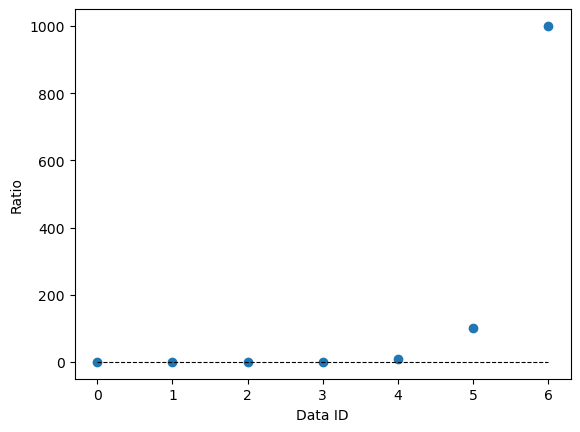

In [3]:
X = np.arange(len(ratio))

plt.scatter(X, ratio)
plt.xlabel("Data ID")
plt.ylabel("Ratio")
plt.hlines(y=1, xmin=X[0], xmax=X[-1], color='black', linestyle='--', linewidth=0.8)


**Q: Is this a good visualization of the ratio data? Why? Why not? Explain.**

A problem of the respective plot that can't exactly visualize the difference in scale of the smaller values. The y axis value for the first four points is hard to be seen, we also can safely say they start from 0 instead of 1.

**Q: Can you fix it?**

Text(0, 0.5, 'Ratio')

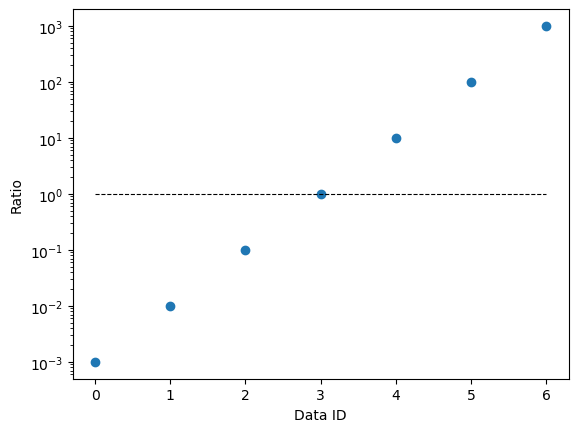

In [4]:
plt.scatter(X, ratio)
plt.hlines(y=1, xmin=X[0], xmax=X[-1], color='black', linestyle='--', linewidth=0.8)
plt.yscale('log')
plt.xlabel("Data ID")
plt.ylabel("Ratio")

## Log-binning

One way to draw a histogram in log-scale, with a broadly distributed data, is by using log-binning.

First, see what happens if we do not use the log scale for a dataset with a heavy tail. 

**Q: Load the movie dataset from `vega_datasets` and remove the NaN rows based on the following three columns: `IMDB_Rating`, `IMDB_Votes`, `Rotten_Tomatoes_Rating`.**

In [5]:
movies = vega_datasets.data.movies()
rows_to_drop =movies[movies['IMDB_Rating'].isna() | (movies['IMDB_Votes'].isna()) | (movies['Rotten_Tomatoes_Rating'].isna())].index
movies.drop(rows_to_drop, inplace=True)

If you simply call `hist()` method with a dataframe object, it identifies all the numeric columns and draws a histogram for each column. 

**Q: draw all possible histograms of the movie dataframe. Adjust the size of the plots if needed.**

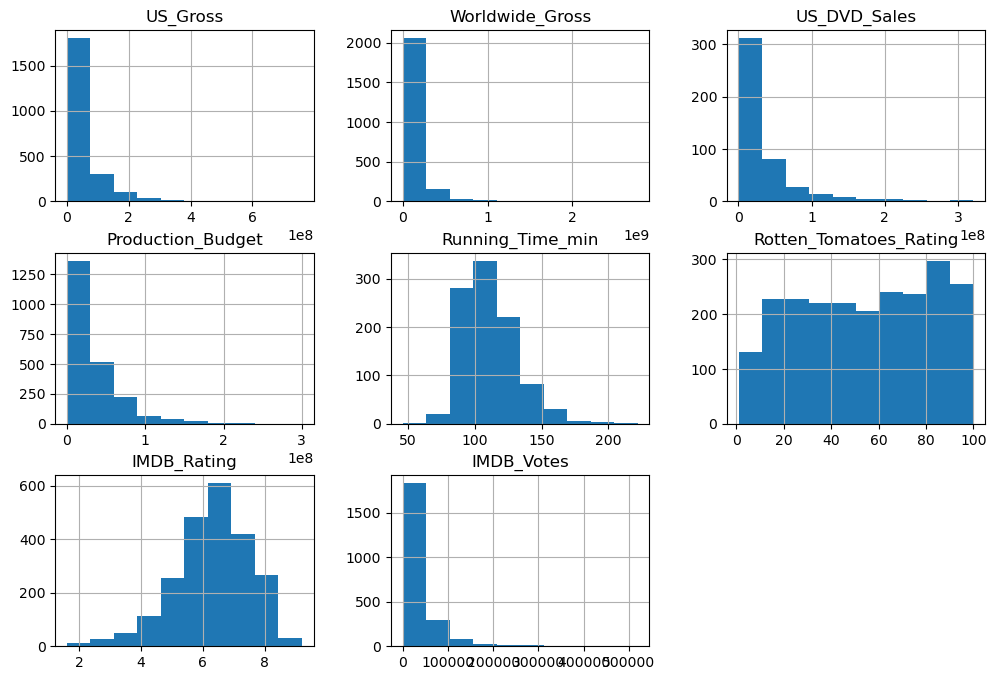

In [6]:

movies.hist(figsize=(12, 8))
plt.show()


As we can see, a majority of the columns are not normally distributed. In particular, if you look at the worldwide gross variable, you only see a couple of meaningful data from the histogram. Is this a problem of resolution? How about increasing the number of bins?

Text(0, 0.5, 'Frequency')

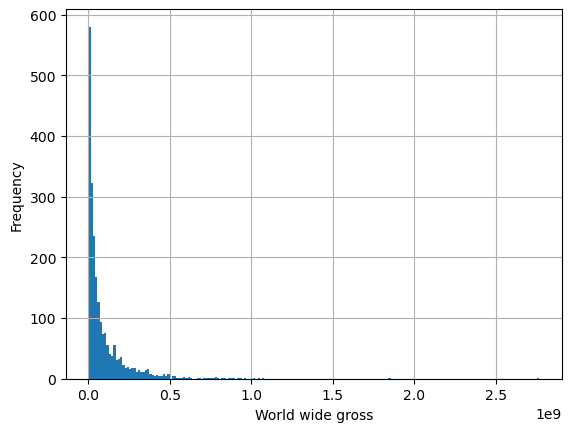

In [7]:
ax = movies["Worldwide_Gross"].hist(bins=200)
ax.set_xlabel("World wide gross")
ax.set_ylabel("Frequency")

Maybe a bit more useful, but it doesn't tell anything about the data distribution above certain point. How about changing the vertical scale to logarithmic scale?

Text(0, 0.5, 'Frequency')

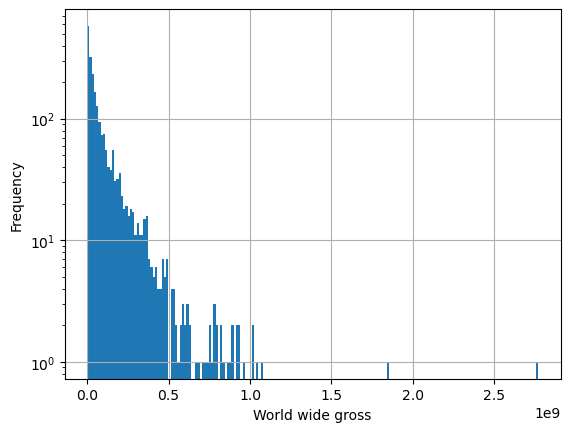

In [8]:
ax = movies["Worldwide_Gross"].hist(bins=200)
ax.set_xlabel("World wide gross")
ax.set_yscale('log')
ax.set_ylabel("Frequency")

Now, let's try log-bin. Recall that when plotting histgrams we can specify the edges of bins through the `bins` parameter. For example, we can specify the edges of bins to [1, 2, 3, ... , 10] as follows.


<Axes: >

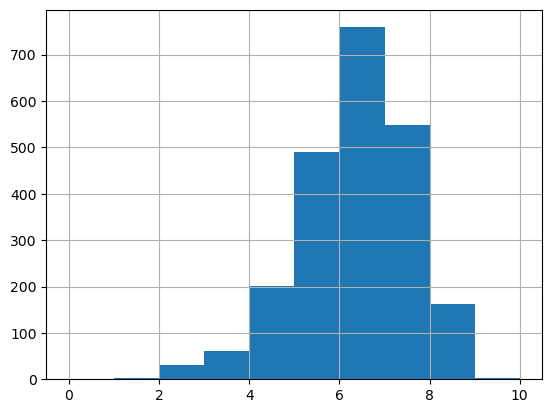

In [9]:
movies["IMDB_Rating"].hist(bins=range(0, 11))

Here, we can specify the edges of bins in a similar way. Instead of specifying on the linear scale, we do it on the log space. Some useful resources:

* [numpy.logspace](http://docs.scipy.org/doc/numpy/reference/generated/numpy.logspace.html)


Hint: since $10^{\text{start}}= \text{min(Worldwide\_Gross)}$, $\text{start} = \log_{10}(\text{min(Worldwide\_Gross)})$

In [10]:
min(movies["Worldwide_Gross"])

0.0

Because there seems to be movie(s) that made $0, and because log(0) is undefined & log(1) = 0, let's add 1 to the variable.  

In [11]:
movies["Worldwide_Gross"] = movies["Worldwide_Gross"] + 1.0

In [12]:
bins = np.logspace(np.log(movies["Worldwide_Gross"].min()), np.log(movies["Worldwide_Gross"].max()), num=20, base=np.e)
bins

array([1.00000000e+00, 3.14018485e+00, 9.86076088e+00, 3.09646119e+01,
       9.72346052e+01, 3.05334634e+02, 9.58807191e+02, 3.01083182e+03,
       9.45456845e+03, 2.96890926e+04, 9.32292387e+04, 2.92757043e+05,
       9.19311230e+05, 2.88680720e+06, 9.06510822e+06, 2.84661155e+07,
       8.93888645e+07, 2.80697558e+08, 8.81442219e+08, 2.76789150e+09])

In [13]:
movies['Worldwide_Gross'].max()

2767891500.0

Now we can plot a histogram with log-bin. Set both axis to be log-scale. 

Text(0, 0.5, 'Frequency')

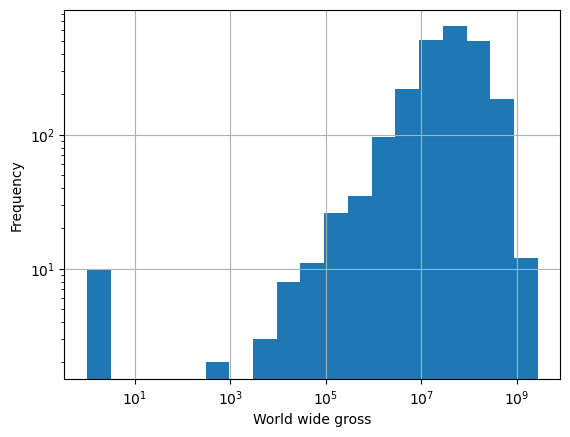

In [14]:
ax = (movies["Worldwide_Gross"] + 1.0).hist(bins=bins)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("World wide gross")
ax.set_ylabel("Frequency")

What is going on? Is this the right plot?

**Q: explain and fix**

The frequency doesn't scale well when data is highly skewed
The discrepancy between the values suggests that the bins on the left can look empty or make spikes due to outliers or noise. 

Text(0, 0.5, 'Probability Density')

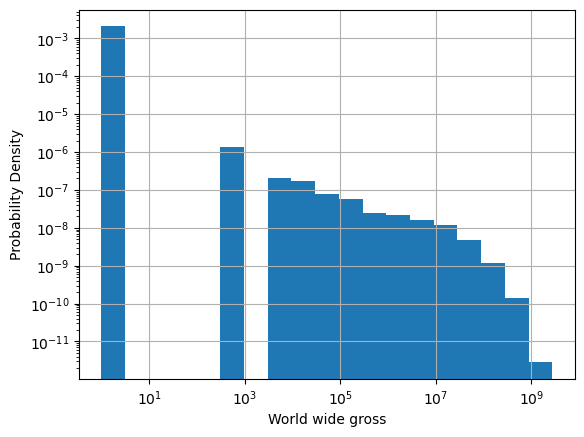

In [15]:
movies["Worldwide_Gross"].hist(bins=bins, density=True, log=True)
plt.xscale("log")
plt.xlabel("World wide gross")
plt.ylabel("Probability Density")


**Q: Can you explain the plot? Why are there gaps?**

Logarithmic Scale amplifies sparse data.
Using a log scale, small differences at the low end can end into big gaps on the graph.
It stretches out the lower-value range, so even small data voids appear as noticeable spaces.

## CCDF

The cumulative distribution function $F_X(x)$ at $x$ is defined by 

$$F_X(x) = P(X \le x),$$ 

which is, in other words, the probability that $X$ takes a value less than or equal to $x$. When empirically calculated (empirical CDF), $F_X(x)$ is the fraction of data points that are less than or equal to $x$. CDF allows us to examine any percentile of the data distribution and is also useful for comparing distributions. 

However, when the data spans multiple orders of magnitude, CDF may not be useful. Let's try. 

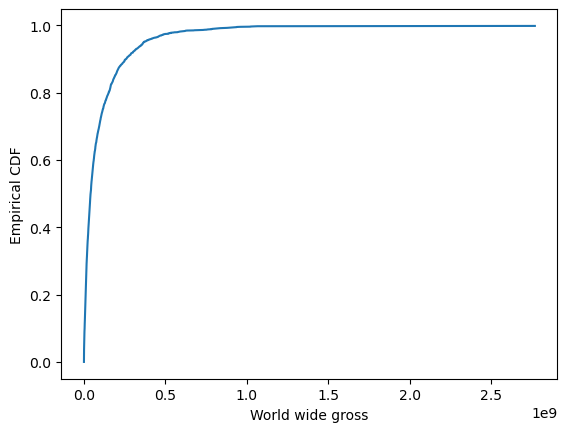

In [16]:
gross_sorted = movies.Worldwide_Gross.sort_values()
N = len(gross_sorted)

Y = np.linspace(1 / N, 1, num=N)
plt.xlabel("World wide gross")
plt.ylabel("Empirical CDF")
_ = plt.plot(gross_sorted, Y)

Although the movies that are interesting are those with large worldwide gross, we don't see any details about their distribution as they are all close to 1. In other words, CDF is bad at revealing the details of the tail.

CCDF is a nice alternative to examine distributions with heavy tails. The idea is same as CDF, but the direction of aggregation is opposite. Because we are starting from the largest value, it can reveal the details of those large values (tail). 

CCDF is defined as follows:

$$ \bar{F}_X(x) = P(X > x)$$

And thus, 

$$ \bar{F}_X(x) = P(X > x) = 1 - F_X(x)$$

In other words, we can use CDF to calculate CCDF.

**Q: draw CCDF using the CDF code above.**

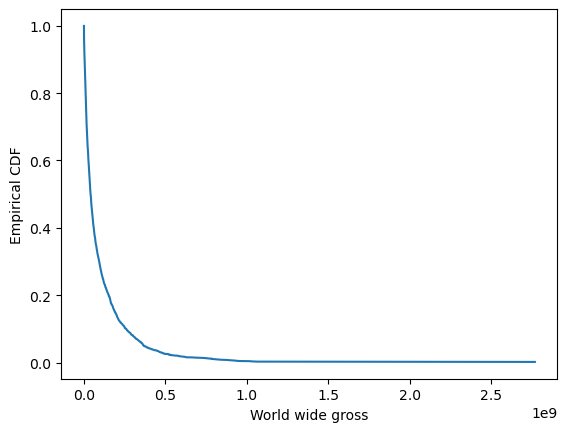

In [17]:
ccdf = 1 - np.linspace(1 / N, 1, num=N)
plt.xlabel("World wide gross")
plt.ylabel("Empirical CDF")
_ = plt.plot(gross_sorted, ccdf)

How about making the y axis in log scale?

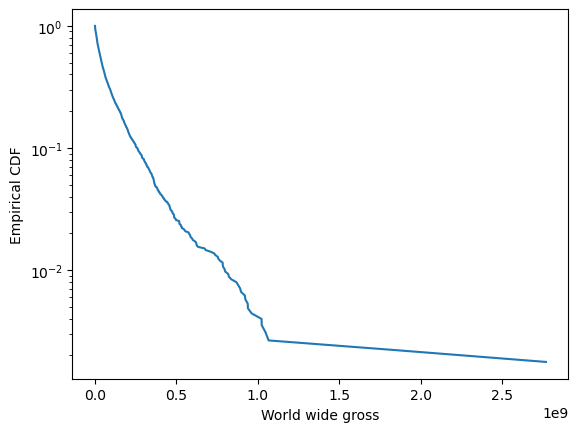

In [18]:
plt.xlabel("World wide gross")
plt.ylabel("Empirical CDF")
plt.yscale("log")
_ = plt.plot(gross_sorted, ccdf)


Although this is technically the correct CCDF plot, there is a very subtle issue. Do you see the vertical line at the rightmost side of the CCDF plot? To understand what's going on, let's look at the Y values of this plot. We used 1 - CDF to calculate CCDF. So,

In [19]:
1 - Y

array([9.99557522e-01, 9.99115044e-01, 9.98672566e-01, ...,
       8.84955752e-04, 4.42477876e-04, 0.00000000e+00], shape=(2260,))

What happens when we take the log of these values?

In [20]:
np.log(1 - Y)

C:\Users\Tudor\AppData\Local\Temp\ipykernel_44860\2469387230.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(1 - Y)


array([-4.42575798e-04, -8.85347557e-04, -1.32831545e-03, ...,
       -7.02997291e+00, -7.72312009e+00,            -inf], shape=(2260,))

Because the last value of 1 - Y is 0.0, we got `-inf` as the log value. That means, the largest value's (let's say $x$) coordinate in our CCDF plot will be $(x, -inf)$ if we use a log scale for our y-axis. And thus we will not be able to see it in the plot. This occurs because we are drawing CDF in a simplified way. In reality, ECDF and ECCDF are step functions and this shouldn't matter. However, because we are drawing a line between the points, we are getting this issue.

This is somewhat problematic because the largest value in our dataset can be quite important and therefore we want to see it in the plot! 

This is why, in practice, we sometimes use "incorrect" version of CCDF. We can consider $\bar{F}_X(x)$ as a "flipped" version of CDF. 

$$ \bar{F}_X(x) = P(X \ge x) $$

instead of 

$$ \bar{F}_X(x) = P(X > x) $$

In doing so, we can see the largest value in the data in our CCDF plot. We can also draw the correct version of CCDF, but this quick-and-dirty version is often easier and good enough to show what we want to show. 

A simple way is just to define the y coordinates as follows:


In [21]:
Y = np.linspace(1.0, 1 / N, num=N)

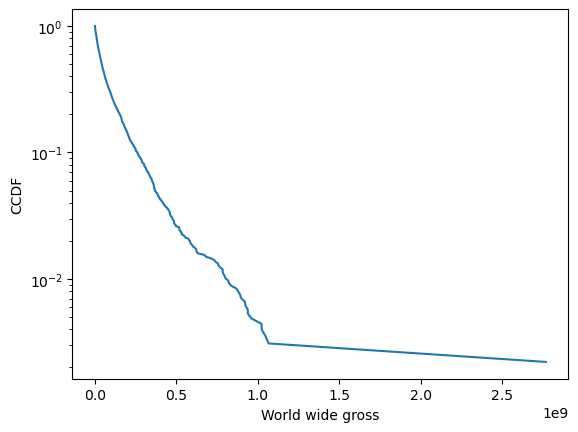

In [22]:
# YOUR SOLUTION HERE
Y = np.linspace(1.0, 1 / N, num=N)

plt.xlabel("World wide gross")
plt.ylabel("CCDF")        # Updated label to match the image
plt.yscale("log")         # Set y-axis to log scale
_ = plt.plot(gross_sorted, Y)
plt.show()

A straight line in semilog scale means exponential decay (cf. a straight line in log-log scale means power-law decay). So it seems like the amount of money a movie makes across the world follows *roughly* an exponential distribution, while there are some outliers that make insane amount of money. 

**Q: Which is the most successful movie in our dataset?**

You can use the following

- `idxmax()`: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.idxmax.html
- `loc`: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.loc.html

In [23]:
# YOUR SOLUTION HERE
idx_max = movies['Worldwide_Gross'].idxmax()
best_movie = movies.loc[idx_max]
best_movie

Title                                  Avatar
US_Gross                          760167650.0
Worldwide_Gross                  2767891500.0
US_DVD_Sales                      146153933.0
Production_Budget                 237000000.0
Release_Date                      Dec 18 2009
MPAA_Rating                             PG-13
Running_Time_min                          NaN
Distributor                  20th Century Fox
Source                    Original Screenplay
Major_Genre                            Action
Creative_Type                 Science Fiction
Director                        James Cameron
Rotten_Tomatoes_Rating                   83.0
IMDB_Rating                               8.3
IMDB_Votes                           261439.0
Name: 1234, dtype: object

# Paired t-test

- Dependencies: scipy pandas seaborn pingouin

In [24]:
import pandas as pd
import scipy.stats as stats
import pingouin as pg

__Paired Sample T-test__

The paired sample t-test is also known as the dependent sample t-test, and paired t-test. This type of t-test compares two averages (means) and will give you information if the difference between these two averages are zero. In a paired sample t-test, each participant is measured twice, which results in pairs of observations. The t-test also tells you whether the differences are statistically significant. In other words it lets you know if those differences could have happened by chance.

__Q: When to use this test?__

For example, if clinical psychologists want to test whether a  treatment for depression will change the quality of life, they might set up an experiment. In this experiment, they will collect information about the participants’ quality of life before the intervention. They are conducting a pre- and post-test study. In the pre-test the average quality of life might be 3, while in the post-test the average quality of life might be  5. Numerically, we could think that the treatment is working. However, it could be due to a fluke and, in order to test this, the clinical researchers can use the paired sample t-test. 

__Hypotheses__

Now, when performing dependent sample t-tests you typically have the following two hypotheses:

1. Null hypotheses: the true mean difference is equal to zero (between the observations), i.e. the means are equal;
2. Alternative hypotheses: the true mean difference is not equal to zero (two-tailed), i.e. the means are different.

Note, in some cases we also may have a specific idea, based on theory, about the direction of the measured effect. For example, we may strongly believe (due to previous research and/or theory) that a specific intervention should have a positive effect. In such a case, the alternative hypothesis will be something like: the true mean difference is greater than zero (one-tailed). Note, it can also be smaller than zero, of course. 

__Assumptions__

Besides that the dependent variable is on interval/ratio scale, and is continuous, there are three assumptions that need to be met:
1. Are the two samples independent?
2. Does the data, i.e., the differences for the matched-pairs, follow a normal distribution?
3. Do the two samples have the same variances?

If your data is not following a normal distribution you can  transform your dependent variable using square root, log, or Box-Cox in Python. In the next section, we will import data.

## data

In [25]:
data = "https://gist.githubusercontent.com/baskaufs/1a7a995c1b25d6e88b45/raw/4bb17ccc5c1e62c27627833a4f25380f27d30b35/t-test.csv"
df = pd.read_csv(data)

df.head()

,grouping,height
0,men,181.5
1,men,187.3
2,men,175.3
3,men,178.3
4,men,169.0


In [26]:
# subset the data
male = df.query('grouping == "men"')["height"]
female = df.query('grouping == "women"')["height"]

__Descriptive statistics__: use the groupby method together with the describe method to calculate summary statistics. As we are interested in the difference between ‘A’ and ‘B’, in the dataset, we used ‘grouping’ as input to the groupby method.

In [27]:
df.groupby("grouping").describe()

height                                                           
          count        mean       std    min     25%    50%     75%    max
grouping                                                                  
men         7.0  179.871429  6.216836  169.0  176.80  181.5  183.85  187.3
women       7.0  171.057143  5.697619  165.2  166.65  170.3  173.75  181.1

## Two-Sample T-Test with Pingouin

In [28]:
pg.ttest(male, female, paired=True)

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,2.85249,6,two-sided,0.029087,"[1.25, 16.38]",1.478192,0.899761,2.973


- Interpreting the P-value

Now, the p-value of the test is 0.029087, which is less than the significance level alpha (e.g., 0.05). Furthermore, this means that we can conclude that the men’s average height is statistically different from the female’s average height. 

Specifically, a p-value is a probability of obtaining an effect at least as extreme as the one in the data you have obtained (i.e., your sample), assuming that the null hypothesis is true. Moreover, p-values address only one question which is concerned about how likely your collected data is, assuming a true null hypothesis? Importantly, it cannot be used as support for the alternative hypothesis.

- Interpreting the Effect Size (Cohen’s D)

One common way to interpret Cohen’s D that is obtained in a t-test is in terms of the relative strength of e.g. the condition. Cohen (1988) suggested that d=0.2 should be considered a ‘small’ effect size, 0.5 is a ‘medium’ effect size, and that 0.8 is a ‘large’ effect size. This means that if two groups’ means don’t differ by 0.2 standard deviations or more, the difference is trivial, even if it is statistically significant.

![interpret ttest](c07_pingouin.jpeg)

## Draw the data

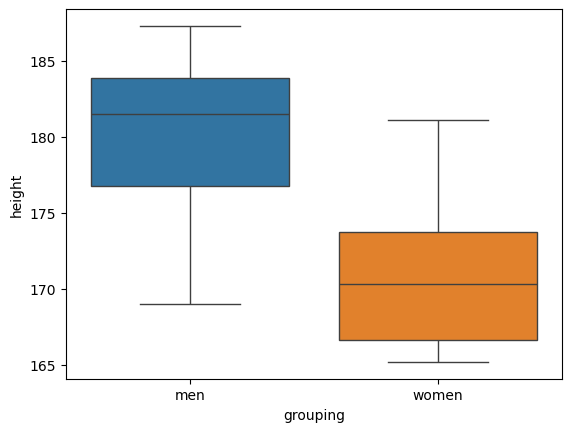

In [29]:
sns.boxplot(data=df, x='grouping', y='height', hue='grouping', legend=False)
plt.xlabel("grouping")
plt.ylabel("height")
plt.show()

In [ ]:
# !jupyter nbconvert --output 'c07_notebook_Ciobanu_Sergiu_Tudor.html' --to html c07.ipynb

[NbConvertApp] Converting notebook c07.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 659196 bytes to c07_notebook_Ciobanu_Sergiu_Tudor.html
